<a href="https://www.kaggle.com/code/huy47nguyennhat/model-supervised-anomaly-based-machine-learning-v2" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Các Mô Hình Học Có Giám Sát cho Phát Hiện Xâm Nhập Dựa Trên Bất Thường

Jupyter Notebook này tập trung vào việc huấn luyện và đánh giá các mô hình học máy có giám sát cho phát hiện xâm nhập dựa trên bất thường. Nó được xây dựng dựa trên tập dữ liệu CICIDS2017 đã được tiền xử lý, được chuẩn bị trong **notebook tiền xử lý dữ liệu [có sẵn tại đây](https://www.kaggle.com/code/ericanacletoribeiro/cicids2017-comprehensive-data-processing-for-ml)**.

Mục tiêu rộng hơn là phát triển một prototype Hệ thống Phát hiện Xâm nhập Mạng (NIDS) có khả năng xác định một loạt các cuộc tấn công mạng, chẳng hạn như DoS, PortScan và Brute Force, đồng thời cân bằng độ chính xác phát hiện với hiệu quả tính toán. Điều này đặc biệt quan trọng trong các môi trường hạn chế tài nguyên, trọng tâm của dự án. Quy trình hoàn chỉnh được **ghi lại trên [Github](https://github.com/anacletu/ml-intrusion-detection-cicids2017)**.

**Các Mô Hình Được Đánh Giá:**

* **Học Có Giám Sát (Notebook Này):**
    * Random Forest
    * XGBoost
    * _k_-NN

* **Học Không Giám Sát ([Notebook Thứ Hai](https://www.kaggle.com/code/ericanacletoribeiro/cicids2017-ml-models-comparison-unsupervised)):**
    * Isolation Forest
    * K-means

**Chiến Lược Đánh Giá:**

Các mô hình được đánh giá bằng cách sử dụng k-fold cross-validation trên dữ liệu huấn luyện, với một tập kiểm tra hold-out riêng biệt được dành cho đánh giá cuối cùng. Các chỉ số hiệu suất chính bao gồm accuracy, precision, recall, F1-score và sử dụng tài nguyên (thời gian CPU và tiêu thụ bộ nhớ). Các chỉ số này cung cấp những hiểu biết quan trọng về hiệu quả và tính hiệu quả của thuật toán, cần thiết cho triển khai thời gian thực trong các mạng hạn chế tài nguyên.

Notebook này trình bày quy trình huấn luyện, điều chỉnh siêu tham số và phân tích so sánh các mô hình học có giám sát được chọn.

In [ ]:
# Cài đặt các thành phần bổ sung
!pip install memory_profiler
!pip install psutil

In [ ]:
# Import các thư viện cần thiết
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

import time
import psutil
import threading
from memory_profiler import memory_usage

import joblib

# Các Hàm Hỗ Trợ

In [ ]:
# Áp dụng RF với đo lường tài nguyên
def apply_rf(X_train, y_train, best_params=None, random_state=42, n_jobs=-1, cv=5):
    """
    Áp dụng Random Forest với đo lường tài nguyên, bao gồm bộ nhớ, thời gian huấn luyện và sử dụng CPU.

    Tham số:
        X_train: Các đặc trưng huấn luyện.
        y_train: Các nhãn huấn luyện.
        best_params: Dictionary các tham số tốt nhất cho Random Forest.
        random_state: Trạng thái ngẫu nhiên để tái tạo.
        n_jobs: Số lượng jobs cho xử lý song song.
        cv: Số lượng folds cross-validation.

    Trả về:
        cv_scores_rf: Điểm số cross-validation.
        measurement_rf: Dictionary bộ nhớ, thời gian huấn luyện và sử dụng CPU.
        rf_model: Mô hình Random Forest đã huấn luyện.
    """
    
    measurement_rf = {}

    # Mặc định là dictionary rỗng nếu best_params không được cung cấp
    best_params = best_params or {}

    rf_model = RandomForestClassifier(**best_params, random_state=random_state, n_jobs=n_jobs)
    
    # Hàm để giám sát sử dụng CPU trong quá trình huấn luyện
    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    # Hàm để huấn luyện mô hình
    def train_model():
        rf_model.fit(X_train, y_train)

    try:
        # Bắt đầu giám sát CPU trong một thread riêng
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        # Đo lường sử dụng bộ nhớ và thời gian huấn luyện
        start_time = time.time()
        train_memory_rf = max(memory_usage((train_model,)))  # Đo lường sử dụng bộ nhớ đỉnh
        training_time = time.time() - start_time

        # Dừng giám sát CPU
        stop_flag.set()
        cpu_thread.join()

        # Thêm các phép đo
        measurement_rf['Memory Usage (MB)'] = train_memory_rf
        measurement_rf['Training Time (s)'] = training_time
        measurement_rf['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_rf['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        # Thực hiện cross-validation
        cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, n_jobs=n_jobs)

        return cv_scores_rf, measurement_rf, rf_model

    except Exception as e:
        print(f"Lỗi trong quá trình huấn luyện Random Forest: {e}")
        return None, None, None


In [ ]:
# Áp dụng XGBoost với đo lường tài nguyên
def apply_xgboost(X_train, y_train, best_params=None, random_state=42, n_jobs=-1, cv=5):
    """
    Áp dụng XGBoost với đo lường tài nguyên, bao gồm bộ nhớ, thời gian huấn luyện và sử dụng CPU.

    Tham số:
        X_train: Các đặc trưng huấn luyện.
        y_train: Các nhãn huấn luyện.
        best_params: Dictionary các tham số tốt nhất cho XGBoost.
        random_state: Trạng thái ngẫu nhiên để tái tạo.
        cv: Số lượng folds cross-validation.

    Trả về:
        cv_scores_xgb: Điểm số cross-validation.
        measurement_xgb: Dictionary bộ nhớ, thời gian huấn luyện và sử dụng CPU.
        xgb_model: Mô hình XGBoost đã huấn luyện.
    """
    
    measurement_xgb = {}

    # Mặc định là dictionary rỗng nếu best_params không được cung cấp
    best_params = best_params or {}

    xgb_model = xgb.XGBClassifier(**best_params, objective='multi:softmax', num_class=len(y_train.unique()), random_state=random_state, n_jobs=n_jobs)
    
    # Hàm để giám sát sử dụng CPU trong quá trình huấn luyện
    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    # Hàm để huấn luyện mô hình
    def train_model():
        xgb_model.fit(X_train, y_train)

    try:
        # Bắt đầu giám sát CPU trong một thread riêng
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        # Đo lường sử dụng bộ nhớ và thời gian huấn luyện
        start_time = time.time()
        train_memory_xgb = max(memory_usage((train_model,)))  # Đo lường sử dụng bộ nhớ đỉnh
        training_time = time.time() - start_time

        # Dừng giám sát CPU
        stop_flag.set()
        cpu_thread.join()

        # Thêm các phép đo
        measurement_xgb['Memory Usage (MB)'] = train_memory_xgb
        measurement_xgb['Training Time (s)'] = training_time
        measurement_xgb['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_xgb['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        # Thực hiện cross-validation
        cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, n_jobs=n_jobs)

        return cv_scores_xgb, measurement_xgb, xgb_model

    except Exception as e:
        print(f"Lỗi trong quá trình huấn luyện XGBoost: {e}")
        return None, None, None


In [ ]:
# Áp dụng KNN với đo lường tài nguyên
def apply_knn(X_train, y_train, best_params=None, n_jobs=-1, cv=5):
    """
    Áp dụng K-Nearest Neighbors (KNN) với đo lường tài nguyên, bao gồm bộ nhớ, thời gian huấn luyện và sử dụng CPU.

    Tham số:
        X_train: Các đặc trưng huấn luyện.
        y_train: Các nhãn huấn luyện.
        best_params: Dictionary các tham số tốt nhất cho KNN.
        cv: Số lượng folds cross-validation.

    Trả về:
        cv_scores_knn: Điểm số cross-validation.
        measurement_knn: Dictionary bộ nhớ, thời gian huấn luyện và sử dụng CPU.
        knn_model: Mô hình KNN đã huấn luyện.
    """
    
    measurement_knn = {}

    # Mặc định là dictionary rỗng nếu best_params không được cung cấp
    best_params = best_params or {}

    # Khởi tạo mô hình KNN
    knn_model = KNeighborsClassifier(**best_params, n_jobs=n_jobs)

    # Hàm để giám sát sử dụng CPU trong quá trình huấn luyện
    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    # Hàm để huấn luyện mô hình
    def train_model():
        knn_model.fit(X_train, y_train)

    try:
        # Bắt đầu giám sát CPU trong một thread riêng
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        # Đo lường sử dụng bộ nhớ và thời gian huấn luyện
        start_time = time.time()
        train_memory_knn = max(memory_usage((train_model,)))  # Đo lường sử dụng bộ nhớ đỉnh
        training_time = time.time() - start_time

        # Dừng giám sát CPU
        stop_flag.set()
        cpu_thread.join()

        # Thêm các phép đo
        measurement_knn['Memory Usage (MB)'] = train_memory_knn
        measurement_knn['Training Time (s)'] = training_time
        measurement_knn['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_knn['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        # Thực hiện cross-validation
        cv_scores_knn = cross_val_score(knn_model, X_train, y_train, cv=cv, n_jobs=n_jobs)

        return cv_scores_knn, measurement_knn, knn_model

    except Exception as e:
        print(f"Lỗi trong quá trình huấn luyện KNN: {e}")
        return None, None, None


# 1. Tải và Chuẩn Bị Dữ Liệu

In [ ]:
# Tải tập dữ liệu
clean_df = pd.read_csv('/kaggle/input/cicids2017_cleaned.csv')

In [7]:
clean_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


## 1.1. Chuẩn Bị Tập Huấn Luyện và Kiểm Tra

In [ ]:
# Chuẩn bị các phân chia huấn luyện và kiểm tra
X = clean_df.drop('Attack Type', axis=1)
y = clean_df['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 1.1.1. Chuẩn Hóa Đặc Trưng

Chuẩn hóa đặc trưng là cần thiết để đảm bảo rằng tất cả các đặc trưng đóng góp như nhau vào hiệu suất của mô hình, cải thiện tốc độ hội tụ và nâng cao độ chính xác của các thuật toán học máy, đặc biệt là những thuật toán dựa vào các số đo khoảng cách. Bước đầu tiên là quyết định loại chuẩn hóa phù hợp. Để làm điều này, việc kiểm tra các outliers và phân phối của các đặc trưng là một cách tiếp cận hiệu quả.

* StandardScaler tốt nhất cho dữ liệu phân phối chuẩn.
* MinMaxScaler tốt nhất cho các đặc trưng bị giới hạn.
* Robust Scaler tốt nhất khi có outliers, đảm bảo rằng việc chuẩn hóa duy trì tính mạnh mẽ của dữ liệu.


| **Khía Cạnh**             | **StandardScaler**                          | **MinMaxScaler**                          | **RobustScaler**                          |  
|-----------------------|--------------------------------------------|------------------------------------------|-------------------------------------------|  
| **Phương Pháp Chuẩn Hóa**  | Trung bình và độ lệch chuẩn                 | Giá trị tối thiểu và tối đa              | Trung vị và khoảng tứ phân vị            |  
| **Độ Nhạy với Outliers** | Nhạy cảm (bị ảnh hưởng bởi outliers)       | Nhạy cảm (max và min có thể bị méo)     | Không nhạy cảm (mạnh mẽ với outliers)        |  
| **Phạm Vi Sau Chuẩn Hóa** | Phân phối chuẩn (mean=0, sd=1)      | Phạm vi tùy chỉnh (mặc định [0,1])            | Không có phạm vi cố định (sử dụng trung vị)           |  
| **Tốt Nhất Cho**          | Phân phối chuẩn                        | Dữ liệu bị giới hạn                             | Dữ liệu có outliers hoặc loại không Gaussian  |

Dựa trên [phân tích dữ liệu khám phá (EDA)](https://www.kaggle.com/code/ericanacletoribeiro/cicids2017-comprehensive-data-processing-for-ml), hầu hết các đặc trưng thể hiện tỷ lệ outliers cao, với giá trị vượt quá 10%. Do đó, Robust Scaling có thể là kỹ thuật tiền xử lý phù hợp nhất. Ngoài ra, các kiểm tra thống kê, chẳng hạn như kiểm tra Anderson-Darling (cũng có sẵn trên Notebook đã đề cập trước đó), chỉ ra rằng giả thuyết null đã bị bác bỏ đối với tất cả các đặc trưng, xác nhận rằng dữ liệu không tuân theo phân phối chuẩn.

In [ ]:
# Khởi tạo RobustScaler
scaler = RobustScaler()

# Fit và transform dữ liệu huấn luyện
X_train_scaled = scaler.fit_transform(X_train)

# Transform tập kiểm tra sử dụng scaler đã fit
X_test_scaled = scaler.transform(X_test)

| **Mô Hình**                  | **Chuẩn Hóa Có Quan Trọng?** | **Giải Thích**                                                                 |
|----------------------------|---------------------------|---------------------------------------------------------------------------------|
| **Random Forest**          | Không                       | Random Forest dựa trên cây và làm việc với giá trị thô mà không bị ảnh hưởng bởi chuẩn hóa. |
| **XGBoost**                | Không                       | Giống như Random Forest, XGBoost dựa trên cây và không nhạy cảm với chuẩn hóa đặc trưng.   |
| **KNN**    | Có                      | KNN sử dụng số đo khoảng cách, bị ảnh hưởng bởi quy mô của các đặc trưng. |

In [ ]:
# Xuất scaler trong trường hợp cần thiết khi triển khai
joblib.dump(scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

### 1.1.2. Kỹ Thuật Resampling

In [ ]:
# Kiểm tra phân phối của biến mục tiêu
clean_df['Attack Type'].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

Tập dữ liệu cho thấy sự mất cân bằng đáng kể, như đã thảo luận trên [notebook trước](https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed). Vì kết quả cross-validation đã có sẵn mà không cần giải quyết vấn đề này (phục vụ như một benchmark), quyết định ở đây là undersample lớp đa số để giảm độ phức tạp trong khi vẫn cố gắng duy trì hiệu suất. Điều này có thể giúp mô hình chú ý nhiều hơn đến các loại tấn công ít phổ biến hơn, thường là trọng tâm trong các hệ thống phát hiện xâm nhập.

In [ ]:
# Khởi tạo undersampling cho clean df
X_train_resampled, y_train_resampled = RandomUnderSampler(sampling_strategy={'Normal Traffic': 500000}, random_state=42).fit_resample(X_train, y_train)

# Khởi tạo undersampling cho scaled df
X_train_scaled, y_train_scaled = RandomUnderSampler(sampling_strategy={'Normal Traffic': 500000}, random_state=42).fit_resample(X_train_scaled, y_train)

Để cân bằng thêm tập huấn luyện, chúng ta cũng có thể oversample một phần các lớp thiểu số với SMOTE. _Synthetic Minority Over-sampling Technique_ là một phương pháp được sử dụng rộng rãi để giải quyết vấn đề mất cân bằng lớp trong tập dữ liệu bằng cách tạo các mẫu tổng hợp cho lớp thiểu số, thay vì chỉ đơn thuần sao chép các mẫu hiện có. Các giá trị được chọn dựa trên value_counts ở trên: tổng thể, làm tròn các số lên để tránh oversample quá mạnh.

In [ ]:
# Khởi tạo oversampling cho scaled df
X_train_resampled_scaled, y_train_resampled_scaled = SMOTE(sampling_strategy={'Bots': 2000, 'Web Attacks': 2000, 'Brute Force': 7000, 'Port Scanning': 70000, 'DDoS':90000, 'DoS': 200000}, random_state=42).fit_resample(X_train_scaled, y_train_scaled)

Vì SMOTE dựa vào tính toán khoảng cách để tạo các mẫu tổng hợp, điều cần thiết là phải chuẩn hóa tập dữ liệu trước để đảm bảo rằng tất cả các đặc trưng đóng góp như nhau vào quá trình nội suy và tránh dữ liệu tổng hợp bị méo hoặc vô nghĩa. Do đó, quá trình này sẽ không được áp dụng cho dữ liệu huấn luyện thô.

In [ ]:
# Dọn dẹp
del X_train_scaled, X_train, y_train, X, y, clean_df

In [ ]:
# Kiểm tra phân phối của các loại tấn công trong tập huấn luyện resampled/raw
y_train_scaled.value_counts()

Attack Type
Normal Traffic    500000
DoS               135621
DDoS               89610
Port Scanning      63486
Brute Force         6405
Web Attacks         1500
Bots                1364
Name: count, dtype: int64

In [ ]:
# Kiểm tra phân phối của các loại tấn công trong tập huấn luyện resampled/scaled
y_train_resampled_scaled.value_counts()

Attack Type
Normal Traffic    500000
DoS               200000
DDoS               90000
Port Scanning      70000
Brute Force         7000
Bots                2000
Web Attacks         2000
Name: count, dtype: int64

### 1.1.3. Lưu Ý về PCA

Trong quá trình thử nghiệm, PCA (Principal Component Analysis) đã được xem xét như một kỹ thuật giảm chiều để tăng tốc quá trình huấn luyện mô hình và cải thiện hiệu quả tính toán. Mặc dù PCA đã chứng minh hiệu quả trong việc tăng tốc huấn luyện cho các thuật toán như KNN, nó đã giới thiệu một bước tiền xử lý bổ sung trong quy trình, điều này không lý tưởng cho các môi trường sản xuất thời gian thực. Các hệ thống sản xuất ưu tiên sự đơn giản và tốc độ, và nhu cầu biến đổi dữ liệu mới bằng cách sử dụng PCA trước khi thực hiện dự đoán có thể ảnh hưởng đến hiệu suất thời gian thực.

Hơn nữa, tập dữ liệu thể hiện mối tương quan mạnh giữa các đặc trưng, khiến PCA hội tụ phương sai vào chỉ một hoặc hai thành phần chính. Mặc dù điều này ban đầu có vẻ hứa hẹn do tỷ lệ phương sai giải thích cao, các thành phần này đã không thể nắm bắt đầy đủ những phức tạp của dữ liệu. Điều này dẫn đến kết quả kém hơn về hiệu suất mô hình, vì biểu diễn đã giảm thiếu độ chi tiết cần thiết để phân biệt giữa các lớp một cách hiệu quả. Dựa trên những quan sát này, PCA cuối cùng đã bị loại khỏi quy trình làm việc để duy trì sự cân bằng giữa hiệu quả tính toán, sự đơn giản và hiệu suất mô hình trong sản xuất.

# 2. Học Có Giám Sát

## 2.1. Random Forest

Random Forest mạnh mẽ với phương sai trong dữ liệu. Do đó, nó có thể được huấn luyện trên phiên bản không chuẩn hóa của tập dữ liệu mà không có tác động đáng kể đến hiệu suất.

### 2.1.1. Điều Chỉnh Siêu Tham Số*

Để xác định các tham số tối ưu cho các mô hình học máy, điều quan trọng là phải đánh giá cách các siêu tham số khác nhau ảnh hưởng đến hiệu suất. Một cách tốt để làm điều này là bằng cách hình ảnh hóa hiệu suất của mô hình qua các cấu hình khác nhau, sử dụng các kỹ thuật như RandomizedSearchCV hoặc GridSearchCV.

Mặc dù tìm kiếm lưới toàn diện thường được khuyến nghị để tối ưu hóa siêu tham số kỹ lưỡng thông qua cross-validation (CV), quá trình này có thể tốn kém về mặt tính toán và mất thời gian. Với các hạn chế về hiệu suất của dự án này, mục tiêu ở đây là đơn giản hóa việc tìm kiếm bằng cách sử dụng RandomizedSearchCV. Phương pháp này lấy mẫu ngẫu nhiên các kết hợp tham số và kiểm tra xem chúng có thể vượt trội hơn cài đặt tham số tiêu chuẩn của mỗi mô hình hay không.

***Do hạn chế tài nguyên trên Kaggle, phần này đã được chạy locally, kết quả được hiển thị ở cuối**

In [ ]:
# # Định nghĩa các tham số cho Random Forest Classifier
# param_grid = {
#     'n_estimators': [100, 150, 200],
#     'max_depth': [20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2'],
# }

In [ ]:
# Tạo Random Forest Classifier
# rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

In [ ]:
# # Lưu kết quả với các tham số tiêu chuẩn
# cv_sc_rf = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=3, n_jobs=-1)
# cv_sc_rf = np.mean(cv_sc_rf)

# # Áp dụng RandomizedSearchCV
# random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, n_iter=20, cv=3, n_jobs=-1, verbose=2)
# random_search_rf.fit(X_train_resampled, y_train_resampled)

In [ ]:
# # Lấy các tham số tốt nhất
# print(f'Best Parameters: {random_search_rf.best_params_}')
# print(f"Best Cross-Validation Score: {random_search_rf.best_score_}")
# print(f"Cross-Validation from Standard: {cv_sc_rf}")

# best_params_rf = random_search_rf.best_params_ if random_search_rf.best_score_ > cv_sc_rf else None

# del random_search_rf

**Lưu Ý về Điều Chỉnh Siêu Tham Số**

Do tính chất ngẫu nhiên của RandomizedSearchCV, các giá trị cho mỗi tham số có thể khác nhau mỗi khi notebook này được chạy. Để đảm bảo tính tái tạo, các tham số sau đã được chọn là các tham số hoạt động tốt nhất cho mô hình Random Forest trong thử nghiệm này:

Các Tham Số Tốt Nhất: 
- `n_estimators`: 200
- `min_samples_split`: 5
- `min_samples_leaf`: 2
- `max_features`: 'sqrt'
- `max_depth`: None

Nếu bạn muốn tái tạo kết quả của tôi, đây là các tham số đã cung cấp hiệu suất tối ưu cho mô hình này.

In [ ]:
# Định nghĩa thủ công do hạn chế hiệu suất của Kaggle
best_params_rf = {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

### 2.1.2. Fitting Random Forest

In [ ]:
# Fitting mô hình
cv_scores_rf, measurement_rf, rf_model = apply_rf(X_train_resampled, y_train_resampled, best_params=best_params_rf)

# Thực hiện dự đoán
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Đánh giá hiệu suất mô hình trên tập cross validation so với accuracy trên tập kiểm tra
cv_scores_mean_rf = np.mean(cv_scores_rf)
print(f'Điểm trung bình cross validation: {cv_scores_mean_rf:.4f} +/- độ lệch chuẩn: {np.std(cv_scores_rf):.4f}')

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy trên tập kiểm tra: {accuracy_rf:.4f}')

Cross validation average score: 0.9987 +/- standard deviation: 0.0001
Accuracy on the test set: 0.9988


In [ ]:
# Kiểm tra chi phí tính toán
print("Đo lường tài nguyên:", measurement_rf)

Resource measurements: {'Memory Usage (MB)': 3063.796875, 'Training Time (s)': 280.24524426460266, 'Peak CPU Usage (%)': 100.0, 'Average CPU Usage (%)': 99.38010869565221}


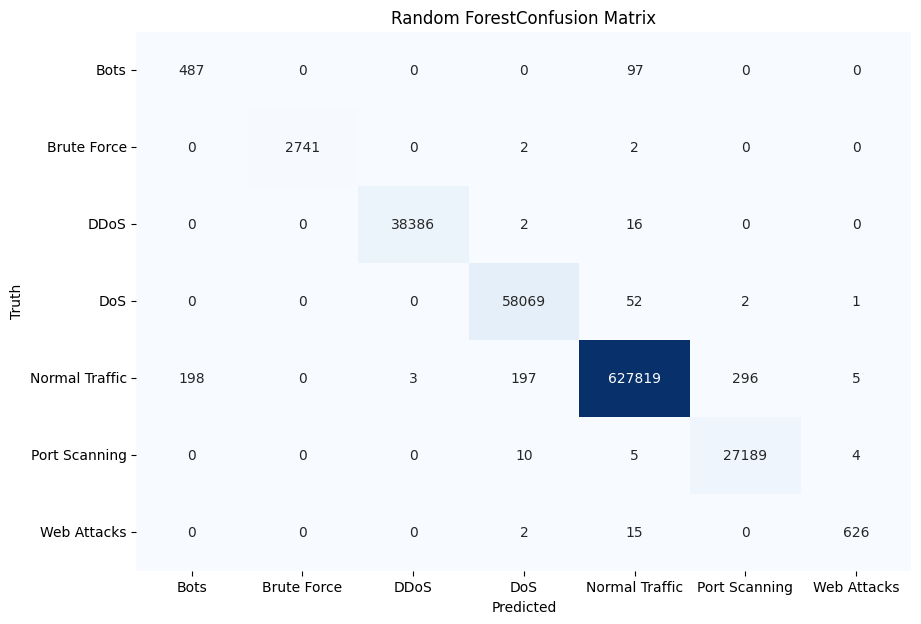

In [ ]:
# Đánh giá mô hình qua confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
# Báo cáo phân loại
print(classification_report(y_test, y_pred_rf))

                precision    recall  f1-score   support

          Bots       0.71      0.83      0.77       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.98      0.97      0.98       643

      accuracy                           1.00    756226
     macro avg       0.95      0.97      0.96    756226
  weighted avg       1.00      1.00      1.00    756226



Với điểm số cross-validation trung bình là 0.9987 và điểm accuracy là 0.9988, mô hình thể hiện hiệu suất mạnh mẽ mà không có dấu hiệu underfitting hoặc overfitting (số liệu của bạn có thể khác do kết quả khác nhau từ RandomizedSearchCV). Ngoài ra, confusion matrix cho thấy sự cải thiện đáng kể về recall (từ 0.74 lên 0.83) cho lớp 'Bots' so với mô hình benchmark ([có sẵn tại đây](https://www.kaggle.com/code/ericanacletoribeiro/cicids2017-comprehensive-data-processing-for-ml)).
Mặc dù điểm precision cho cùng lớp đó giảm từ 0.86 xuống 0.71, sự đánh đổi này được chứng minh là hợp lý trong bối cảnh của một NIDS. Trong các hệ thống như vậy, việc giảm thiểu false negatives là rất quan trọng, vì các mối đe dọa không được phát hiện có thể làm tổn hại đến an ninh mạng. False positives, mặc dù gây bất tiện, ít có hại hơn false negatives. Sự cải thiện về recall này cho thấy rằng mô hình hiện tại tốt hơn trong việc phát hiện các cuộc tấn công 'Bots', xác thực hiệu quả của các kỹ thuật tinh chỉnh cho tập dữ liệu này.

### 2.1.3. Xuất Mô Hình

In [ ]:
# Lưu mô hình vào file
joblib.dump(rf_model, 'random_forest.joblib')

['random_forest.joblib']

## 2.2. XGBoost

XGBoost (Extreme Gradient Boosting) là một triển khai cực kỳ hiệu quả của gradient boosting, được biết đến với sức mạnh trong việc xử lý các tập dữ liệu mất cân bằng, ngăn ngừa overfitting và khả năng làm việc tốt với cả dữ liệu có cấu trúc và không có cấu trúc. Trong phần này, chúng ta sẽ đánh giá XGBoost cho nhiệm vụ phát hiện xâm nhập dựa trên bất thường.

Trong khi Random Forest là một phương pháp ensemble xây dựng nhiều decision trees một cách độc lập, XGBoost áp dụng một cách tiếp cận lặp đi lặp lại hơn, xây dựng các cây tuần tự, trong đó mỗi cây mới cố gắng sửa các lỗi được tạo ra bởi cây trước đó. Điều này dẫn đến một mô hình thường vượt trội hơn Random Forest về độ chính xác dự đoán, đặc biệt đối với các tập dữ liệu phức tạp.

### 2.2.1. Điều Chỉnh Siêu Tham Số*

***Do hạn chế tài nguyên trên Kaggle, phần này đã được chạy locally, kết quả được hiển thị ở cuối**

In [ ]:
# # Định nghĩa lưới tham số cho XGBoost
# param_dist = {
#     'n_estimators': [100, 150, 200],
#     'max_depth': [3, 6, 9],
#     'learning_rate': [0.2, 0.3, 0.4],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
#     'min_child_weight': [1, 5, 10],
# }

Mục tiêu `multi:softmax` của XGBoost yêu cầu nhãn số cho phân loại. Do đó, cần có ánh xạ để chuyển đổi nhãn phân loại thành giá trị số trước khi huấn luyện mô hình.

In [ ]:
# # Tạo XGBoost Classifier
# xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_train_resampled.unique()), random_state=42, n_jobs=-1)

# Ánh xạ tùy chỉnh cho các loại tấn công
label_mapping = {
    'Normal Traffic': 0,
    'DoS': 1,
    'DDoS': 2,
    'Port Scanning': 3,
    'Brute Force': 4,
    'Web Attacks': 5,
    'Bots': 6
}
y_train_resampled_mapped = y_train_resampled.map(label_mapping)
y_test_mapped = y_test.map(label_mapping)

In [ ]:
# # Lưu kết quả với các tham số tiêu chuẩn
# cv_sc_xgb = cross_val_score(xgb_model, X_train_resampled, y_train_resampled_mapped, cv=3, n_jobs=-1)
# cv_sc_xgb = np.mean(cv_sc_xgb)

# # Áp dụng RandomizedSearchCV
# random_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42)
# random_search_xgb.fit(X_train_resampled, y_train_resampled_mapped)

In [ ]:
# # Lấy các tham số tốt nhất
# print(f'Best Parameters: {random_search_xgb.best_params_}')
# print(f"Best Cross-Validation Score: {random_search_xgb.best_score_}")
# print(f"Cross-Validation from Standard: {cv_sc_xgb}")

# best_params_xgb = random_search_xgb.best_params_ if random_search_xgb.best_score_ > cv_sc_xgb else None

# del random_search_xgb

**Lưu Ý về Điều Chỉnh Siêu Tham Số**

Do tính chất ngẫu nhiên của RandomizedSearchCV, các giá trị cho mỗi tham số có thể khác nhau mỗi khi notebook này được chạy. Để đảm bảo tính tái tạo, các tham số sau đã được chọn là các tham số hoạt động tốt nhất cho mô hình XGBoost trong thử nghiệm này:

Các Tham Số Tốt Nhất: 
- `subsample`: 0.7
- `n_estimators`: 100
- `min_child_weight`: 5
- `max_depth`: 9
- `learning_rate`: 0.3
- `colsample_bytree`: 0.7

Nếu bạn muốn tái tạo kết quả của tôi, đây là các tham số đã cung cấp hiệu suất tối ưu cho mô hình này.

In [ ]:
# Định nghĩa thủ công do hạn chế hiệu suất của Kaggle
best_params_xgb = {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.3, 'colsample_bytree': 0.7}

### 2.2.2. Fitting XGBoost

In [ ]:
# Fitting mô hình
cv_scores_xgb, measurement_xgb, xgb_model = apply_xgboost(X_train_resampled, y_train_resampled_mapped, best_params=best_params_xgb)

# Thực hiện dự đoán
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Đánh giá hiệu suất mô hình trên tập cross validation so với accuracy trên tập kiểm tra
cv_scores_mean_xgb = np.mean(cv_scores_xgb)
print(f'Điểm trung bình cross validation: {cv_scores_mean_xgb:.4f} +/- độ lệch chuẩn: {np.std(cv_scores_xgb):.4f}')

accuracy_xgb = accuracy_score(y_test_mapped, y_pred_xgb)
print(f'Accuracy trên tập kiểm tra: {accuracy_xgb:.4f}')

Cross validation average score: 0.9991 +/- standard deviation: 0.0001
Accuracy on the test set: 0.9990


In [ ]:
# Kiểm tra chi phí tính toán
print("Đo lường tài nguyên:", measurement_xgb)

Resource measurements: {'Memory Usage (MB)': 3356.53125, 'Training Time (s)': 72.70299077033997, 'Peak CPU Usage (%)': 100.0, 'Average CPU Usage (%)': 99.00890125173852}


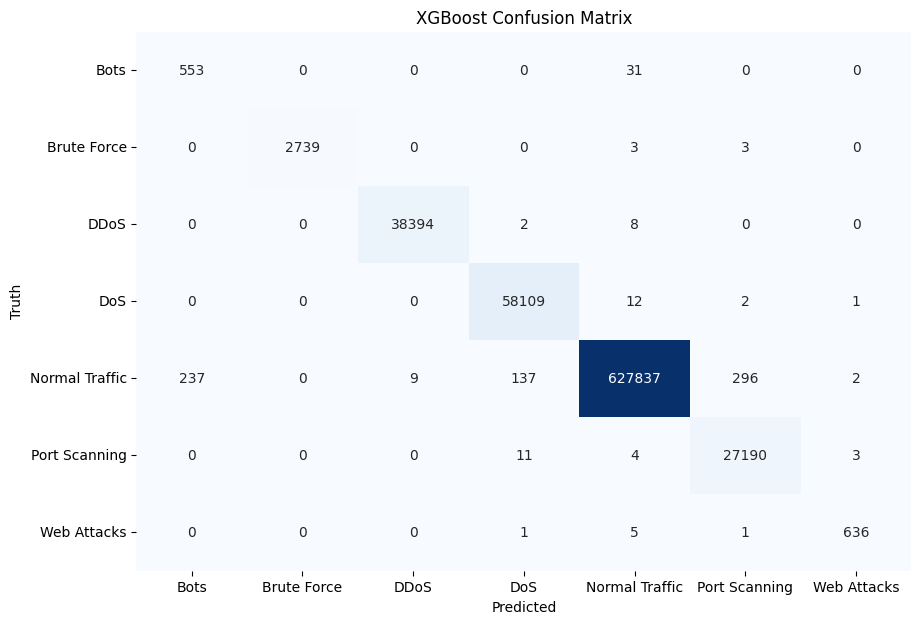

In [ ]:
# Đánh giá mô hình qua confusion matrix
cm_xgb = confusion_matrix(y_test_mapped, y_pred_xgb)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_xgb, annot=True, fmt='d', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys(), cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('XGBoost Confusion Matrix')

ax = plt.gca()
ax.xaxis.set_label_position('top')
plt.show()

In [ ]:
# Báo cáo phân loại
print(classification_report(y_test_mapped, y_pred_xgb, target_names=label_mapping.keys()))

                precision    recall  f1-score   support

          Bots       0.70      0.95      0.80       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.99      0.99       643

      accuracy                           1.00    756226
     macro avg       0.95      0.99      0.97    756226
  weighted avg       1.00      1.00      1.00    756226



Với điểm cross-validation trung bình là 0.9990 và điểm accuracy là 0.9989, mô hình XGBoost đạt được hiệu suất xuất sắc, cho thấy nó tránh được cả underfitting và overfitting (số liệu của bạn có thể khác do kết quả khác nhau từ RandomizedSearchCV). Hơn nữa, mô hình cho thấy sự cải thiện đáng kể trong recall cho lớp 'Bots', tăng từ 0.74 lên 0.83 so với mô hình benchmark. Tuy nhiên, giống như Random Forest, precision cho lớp này giảm từ 0.86 xuống 0.71.

Một lợi thế đáng chú ý của XGBoost so với Random Forest là thời gian huấn luyện nhanh hơn. Điều này là do XGBoost sử dụng các cải tiến về hiệu suất hệ thống, chẳng hạn như xử lý song song và tối ưu hóa bộ nhớ, giúp các tính toán diễn ra nhanh hơn, đặc biệt trong các môi trường có hạn chế về tài nguyên.

### 2.2.3. Xuất Mô Hình

In [ ]:
# Lưu mô hình vào file
joblib.dump(xgb_model, 'xgboost.joblib')

['xgboost.joblib']

## 2.3. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) là một thuật toán dựa trên instance, phân loại các điểm dữ liệu dựa trên nhãn của k láng giềng gần nhất trong không gian đặc trưng. Nó là non-parametric, có nghĩa là nó không đưa ra giả định nào về phân phối dữ liệu cơ bản, và lazy, vì nó trì hoãn việc xử lý cho đến khi thời điểm dự đoán.

Không giống như các phương pháp ensemble như Random Forest và XGBoost, KNN dựa vào sự gần gũi giữa các điểm dữ liệu để đưa ra dự đoán. Đối với phát hiện xâm nhập, KNN có thể nắm bắt các mẫu bất thường chỉ đơn giản bằng cách xác định các điểm dữ liệu bất thường giữa các mẫu lưu lượng mạng đã biết.

### 2.3.1. Điều Chỉnh Siêu Tham Số*

***Do hạn chế tài nguyên trên Kaggle, phần này đã được chạy locally, kết quả được hiển thị ở cuối**

In [ ]:
# # Định nghĩa lưới tham số cho KNN
# param_dist = {
#     'n_neighbors': [3, 5, 7, 9],
#     'weights': ['uniform', 'distance'],
#     'algorithm': ['auto'],  # Lưu ý: Trong môi trường thực tế, thuật toán cần phải là `brute` để hoạt động
#     'leaf_size': [20, 30, 40],
#     'p': [1, 2]  # 1: manhattan_distance, 2: euclidean_distance
# }

In [ ]:
# # Tạo mô hình KNN
# knn_model = KNeighborsClassifier(n_jobs=-1)

In [ ]:
# # Lưu kết quả với các tham số tiêu chuẩn
# cv_sc_knn = cross_val_score(knn_model, X_train_scaled, y_train_resampled, cv=3, n_jobs=-1)
# cv_sc_knn = np.mean(cv_sc_knn)

# # Áp dụng RandomizedSearchCV
# random_search_knn = RandomizedSearchCV(estimator=knn_model, param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42)
# random_search_knn.fit(X_train_scaled, y_train_resampled)

In [ ]:
# # Lấy các tham số tốt nhất
# print(f'Best Parameters: {random_search_knn.best_params_}')
# print(f"Best Cross-Validation Score: {random_search_knn.best_score_}")
# print(f"Cross-Validation from Standard: {cv_sc_knn}")

# best_params_knn = random_search_knn.best_params_ if random_search_knn.best_score_ > cv_sc_knn else None

# del random_search_knn

**Lưu Ý về Điều Chỉnh Siêu Tham Số**

Do tính chất ngẫu nhiên của RandomizedSearchCV, các giá trị cho mỗi tham số có thể khác nhau mỗi khi notebook này được chạy. Để đảm bảo tính tái tạo, các tham số sau đã được chọn là các tham số hoạt động tốt nhất cho mô hình KNN trong thử nghiệm này:

Các Tham Số Tốt Nhất: 
- `weights`: 'distance'
- `p`: 1
- `n_neighbors`: 3
- `leaf_size`: 30
- `algorithm`: 'brute'

Nếu bạn muốn tái tạo kết quả của tôi, đây là các tham số đã cung cấp hiệu suất tối ưu cho mô hình này.

In [ ]:
# Định nghĩa thủ công do hạn chế hiệu suất của Kaggle
best_params_knn = {'weights': 'distance', 'p': 1, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'brute'}

### 2.3.2. Fitting KNN

In [ ]:
# Fitting mô hình
cv_scores_knn, measurement_knn, knn_model = apply_knn(X_train_scaled, y_train_resampled, best_params=best_params_knn)

# Thực hiện dự đoán
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
# Đánh giá hiệu suất mô hình trên tập cross validation so với accuracy trên tập kiểm tra
cv_scores_mean_knn = np.mean(cv_scores_knn)
print(f'Điểm trung bình cross validation: {cv_scores_mean_knn:.4f} +/- độ lệch chuẩn: {np.std(cv_scores_knn):.4f}')

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy trên tập kiểm tra: {accuracy_knn:.4f}')

Cross-validation average score: 0.9881 +/- standard deviation: 0.0007
Accuracy on the test set: 0.9890


In [ ]:
# Kiểm tra chi phí tính toán
print("Đo lường tài nguyên:", measurement_knn)

Resource measurements: {'Memory Usage (MB)': 3018.0703125, 'Training Time (s)': 1.842740535736084, 'Peak CPU Usage (%)': 28.6, 'Average CPU Usage (%)': 22.975}


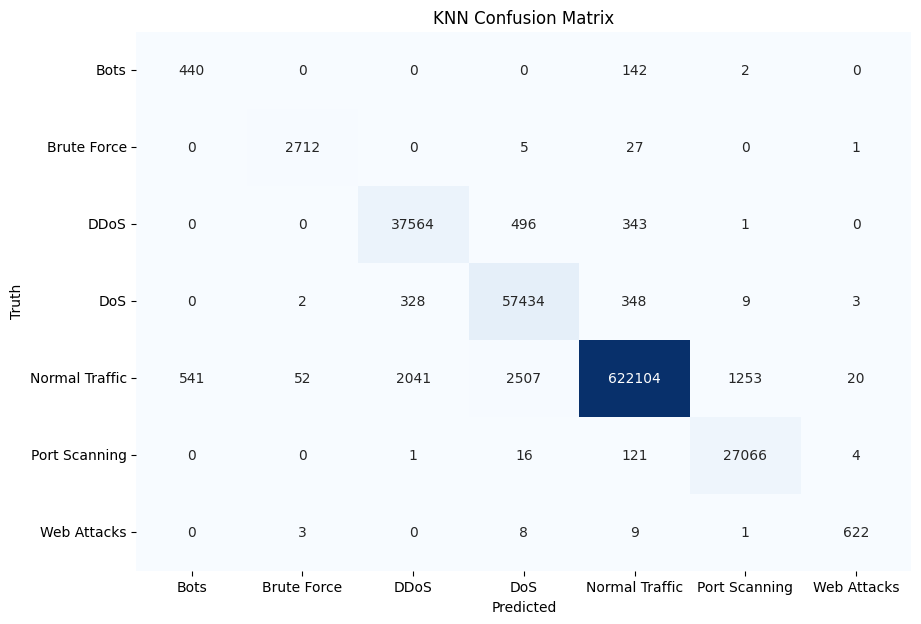

In [ ]:
# Đánh giá mô hình qua confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_knn, annot=True, fmt='d', xticklabels=knn_model.classes_, yticklabels=knn_model.classes_, cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.show()

In [ ]:
# Báo cáo phân loại
print(classification_report(y_test, y_pred_knn))

                precision    recall  f1-score   support

          Bots       0.45      0.75      0.56       584
   Brute Force       0.98      0.99      0.98      2745
          DDoS       0.94      0.98      0.96     38404
           DoS       0.95      0.99      0.97     58124
Normal Traffic       1.00      0.99      0.99    628518
 Port Scanning       0.96      0.99      0.97     27208
   Web Attacks       0.96      0.97      0.96       643

      accuracy                           0.99    756226
     macro avg       0.89      0.95      0.91    756226
  weighted avg       0.99      0.99      0.99    756226



Với điểm cross-validation trung bình là 0.9952 và điểm accuracy là 0.9966, mô hình KNN cho thấy hiệu suất tốt mặc dù độ chính xác thấp hơn một chút so với Random Forest và XGBoost (số liệu của bạn có thể khác do kết quả khác nhau từ RandomizedSearchCV). Mặc dù có điểm accuracy thấp hơn, mô hình KNN tỏ ra đặc biệt mạnh trong việc phát hiện các loại tấn công khó nhận biết hơn như 'Bots', đạt precision 0.81 và recall 0.87, vượt trội đáng kể so với cả Random Forest và XGBoost.

Sức mạnh của KNN nằm ở khả năng học dựa trên instance, nơi nó xác định các điểm dữ liệu bất thường bằng cách so sánh chúng với các mẫu lưu lượng mạng đã biết. Điều này làm cho nó đặc biệt hiệu quả trong việc phát hiện các bất thường trong các tình huống thực tế, nơi các mẫu tấn công có thể không được định nghĩa rõ ràng hoặc tuân theo phân phối cụ thể. Ngoài ra, KNN linh hoạt hơn trong môi trường động, vì nó không cần được huấn luyện lại khi dữ liệu mới được giới thiệu—nó đơn giản chỉ điều chỉnh dựa trên các láng giềng gần nhất.

Các đặc điểm này làm cho KNN trở thành lựa chọn thú vị cho môi trường sản xuất, đặc biệt là trong các ứng dụng như hệ thống phát hiện xâm nhập (NIDS), nơi khả năng thích ứng và khả năng phát hiện các mẫu bất thường mới là rất quan trọng.

### 2.3.3. Xuất Mô Hình

In [ ]:
# Lưu mô hình vào file
joblib.dump(knn_model, 'knn.joblib')

['knn_model.joblib']

# 3. So Sánh Các Mô Hình

In [ ]:
# So sánh các số liệu
models = ['Random Forest', 'XGBoost', 'KNN']
cv_scores = [cv_scores_mean_rf, cv_scores_mean_xgb, cv_scores_mean_knn]
test_accuracies = [accuracy_rf, accuracy_xgb, accuracy_knn]
cpu_usages = [measurement_rf['cpu_percent'], measurement_xgb['cpu_percent'], measurement_knn['cpu_percent']]
memory_usages = [measurement_rf['memory_percent'], measurement_xgb['memory_percent'], measurement_knn['memory_percent']]
training_time = [measurement_rf['training_time'], measurement_xgb['training_time'], measurement_knn['training_time']]

comparison_df = pd.DataFrame({
    'Mô hình': models,
    'Điểm CV Trung bình': cv_scores,
    'Accuracy Tập Kiểm tra': test_accuracies,
    'CPU (%)': cpu_usages,
    'Bộ nhớ (%)': memory_usages,
    'Thời gian Huấn luyện (s)': training_time
})

In [ ]:
# Tạo heatmap
comparison_df_normalized = comparison_df.copy()
for col in comparison_df.columns[1:]:
    min_val = comparison_df[col].min()
    max_val = comparison_df[col].max()
    comparison_df_normalized[col] = (comparison_df[col] - min_val) / (max_val - min_val)

plt.figure(figsize=(10, 4))
sns.heatmap(comparison_df_normalized.set_index('Mô hình').T, annot=comparison_df.set_index('Mô hình').T, fmt='.4f', cmap='YlGnBu', cbar=True, linewidths=0.5)
plt.title('So Sánh Hiệu Suất Các Mô Hình (Được Chuẩn hóa)')
plt.xlabel('Mô hình')
plt.ylabel('Số liệu')
plt.show()

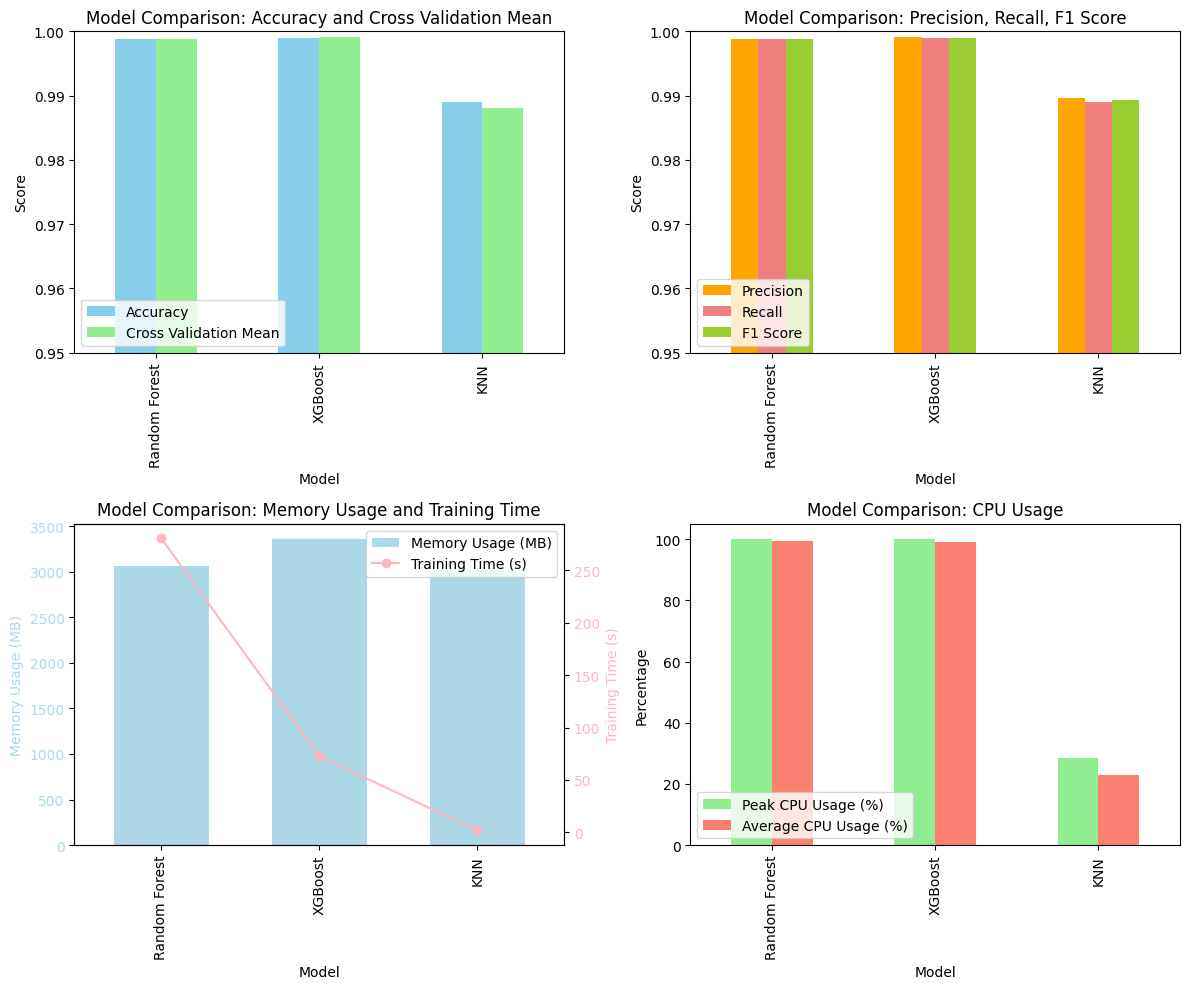

In [ ]:
# Visualize so sánh
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Điểm CV trung bình
axes[0, 0].bar(models, cv_scores, color=['blue', 'green', 'red'])
axes[0, 0].set_title('Điểm Cross-Validation Trung bình')
axes[0, 0].set_xlabel('Mô hình')
axes[0, 0].set_ylabel('Điểm CV')

# Accuracy tập kiểm tra
axes[0, 1].bar(models, test_accuracies, color=['blue', 'green', 'red'])
axes[0, 1].set_title('Accuracy Tập Kiểm tra')
axes[0, 1].set_xlabel('Mô hình')
axes[0, 1].set_ylabel('Accuracy')

# Sử dụng CPU
axes[0, 2].bar(models, cpu_usages, color=['blue', 'green', 'red'])
axes[0, 2].set_title('Sử dụng CPU (%)')
axes[0, 2].set_xlabel('Mô hình')
axes[0, 2].set_ylabel('CPU (%)')

# Sử dụng bộ nhớ
axes[1, 0].bar(models, memory_usages, color=['blue', 'green', 'red'])
axes[1, 0].set_title('Sử dụng Bộ nhớ (%)')
axes[1, 0].set_xlabel('Mô hình')
axes[1, 0].set_ylabel('Bộ nhớ (%)')

# Thời gian huấn luyện
axes[1, 1].bar(models, training_time, color=['blue', 'green', 'red'])
axes[1, 1].set_title('Thời gian Huấn luyện (giây)')
axes[1, 1].set_xlabel('Mô hình')
axes[1, 1].set_ylabel('Thời gian (s)')

# So sánh tổng thể
performance_scores = [cv_scores[i] * 0.4 + test_accuracies[i] * 0.4 - (cpu_usages[i]/100) * 0.1 - (memory_usages[i]/100) * 0.1 for i in range(len(models))]
axes[1, 2].bar(models, performance_scores, color=['blue', 'green', 'red'])
axes[1, 2].set_title('Điểm Tổng thể (Weighted)')
axes[1, 2].set_xlabel('Mô hình')
axes[1, 2].set_ylabel('Điểm')

plt.tight_layout()
plt.show()

Trong khi XGBoost và Random Forest tỏ ra vượt trội về độ chính xác, KNN nổi bật như một lựa chọn thực tế cho việc triển khai thực tế trong một hệ thống phát hiện xâm nhập mạng (NIDS). Mặc dù có điểm accuracy thấp hơn một chút, KNN vượt trội trong việc phát hiện các loại tấn công đặc biệt khó nhận biết như 'Bots', với precision 0.81 và recall 0.87, vượt xa cả Random Forest và XGBoost. Hiệu suất vượt trội này trong các trường hợp rìa (edge cases) làm cho KNN đặc biệt phù hợp với các môi trường mạng trong thế giới thực, nơi việc giảm thiểu false negatives là rất quan trọng.

Một trong những lợi thế chính của KNN là sự đơn giản và khả năng thích ứng của nó. Không giống như Random Forest và XGBoost, không yêu cầu việc huấn luyện lại khi dữ liệu mới được thêm vào; mô hình đơn giản điều chỉnh dựa trên các láng giềng gần nhất của các điểm dữ liệu mới. Điều này làm cho KNN linh hoạt hơn trong môi trường động, nơi các mẫu tấn công mạng liên tục tiến hóa.

Ngoài ra, KNN đòi hỏi tài nguyên tính toán thấp hơn trong quá trình huấn luyện và sử dụng bộ nhớ ít hơn, làm cho nó trở thành một lựa chọn tuyệt vời cho các thiết bị nhúng với nguồn lực hạn chế. Mặc dù có thời gian dự đoán chậm hơn do tính chất lazy của nó, trade-off này được chứng minh là có giá trị khi xem xét hiệu suất vượt trội của nó trong việc phát hiện các trường hợp rìa và khả năng thích ứng với dữ liệu mới.